In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer



# Load data

In [2]:
df = pd.read_csv("online_shoppers_intention.csv")

In [ ]:
# Sprawdzenie podstawowych informacji
df.info()

# Sprawdzenie brakujących wartości
print(df.isnull().sum())

# Usunięcie duplikatów
print(f"Liczba duplikatów przed: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Kształt danych po usunięciu duplikatów: {df.shape}")

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

C:\Users\janas\AppData\Local\Temp\ipykernel_26460\4248971506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=df, palette='viridis')


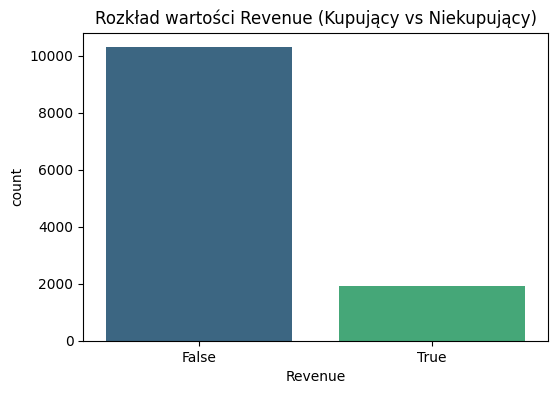

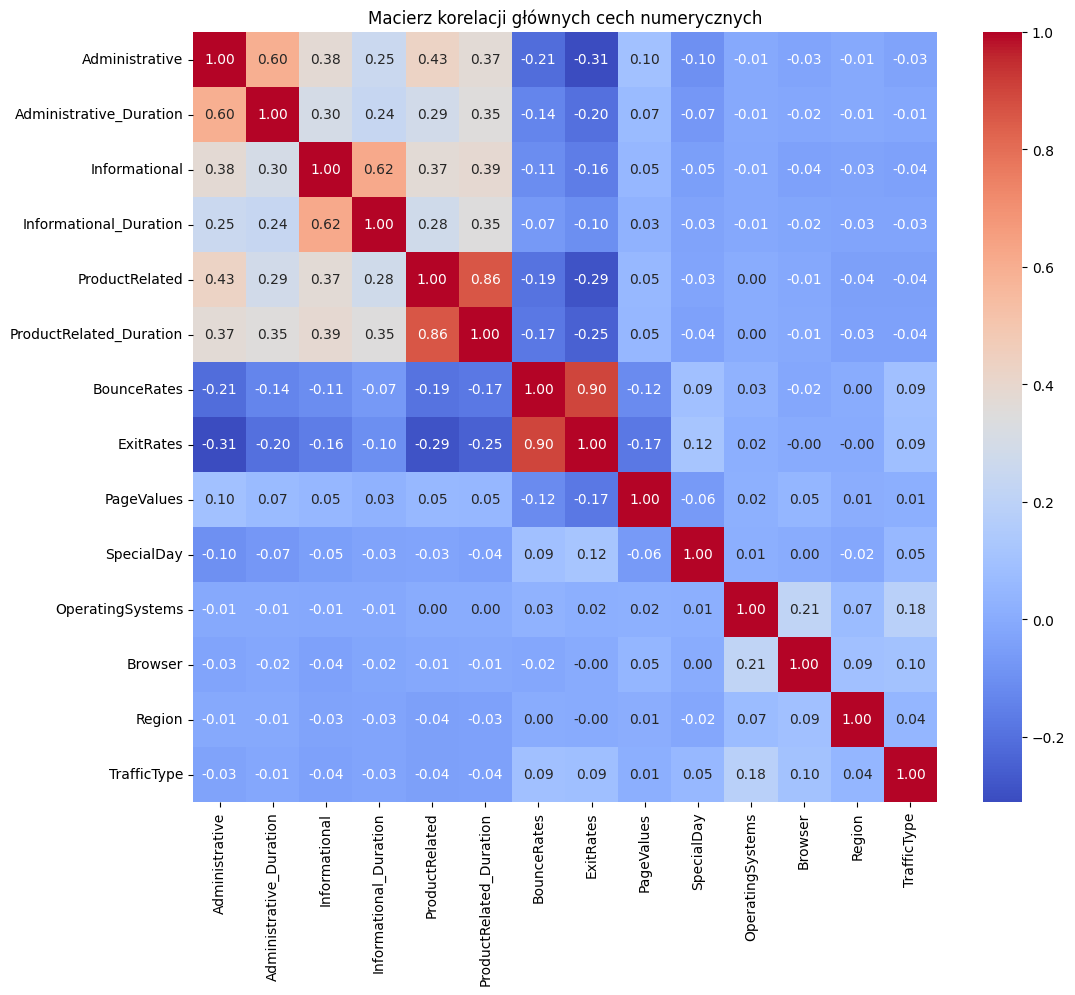

In [4]:
# 1. Wykres balansu klas
plt.figure(figsize=(6, 4))
sns.countplot(x='Revenue', data=df, palette='viridis')
plt.title('Rozkład wartości Revenue (Kupujący vs Niekupujący)')
plt.show()

# 2. Macierz korelacji głównych cech numerycznych
plt.figure(figsize=(12, 10))
# Generujemy macierz korelacji tylko dla cech numerycznych oryginalnego zbioru
correlation_matrix = df.select_dtypes(include='number').corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Macierz korelacji głównych cech numerycznych')
plt.show()

# Split data into X, y

In [5]:
# 1. Procedura izolacji struktury i zapobiegania wyciekom danych
X = df.drop(columns=['Revenue'])
y = df['Revenue'].astype(int)

# Transform and preprocess data

We can express cyclical values as trigonometric values to show "closeness" of Jan and Dec.
We use OHE and Standard Scaler

In [6]:

X['Weekend'] = X['Weekend'].astype(int)

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Definicja operacji transformacji cyklicznej, zamknięta w funkcji
def sin_cos_transform(X_col):
    month_map = {
        'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
        'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
    }
    # Ujednolicenie na typ pd.Series w celu poprawnego mapowania
    X_series = pd.Series(X_col.ravel()) if isinstance(X_col, np.ndarray) else X_col.iloc[:, 0]
    X_num = X_series.map(month_map)
    # Zabezpieczenie przed brakami danych poprzez imputację miarą tendencji centralnej (dominanta)
    X_num = X_num.fillna(X_num.mode()[0])
    
    sin_feat = np.sin(2 * np.pi * X_num / 12)
    cos_feat = np.cos(2 * np.pi * X_num / 12)
    return np.column_stack([sin_feat, cos_feat])

# 4. Kategoryzacja przestrzeni atrybutów bazując na zbiorze Online Shoppers
nominal_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType']
cyclic_cols = ['Month']
passthrough_cols = ['Weekend']

# Dynamiczna ekstrakcja zmiennych wyłącznie ilościowych ciągłych i dyskretnych
numerical_cols = [col for col in X.columns if col not in nominal_cols + cyclic_cols + passthrough_cols]

# 5. Konstrukcja zintegrowanego modelu przetwarzania
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), nominal_cols),
        ('cyclic', FunctionTransformer(sin_cos_transform), cyclic_cols),
        ('pass', 'passthrough', passthrough_cols)
    ])

# Estymacja parametrów na zbiorze treningowym; rzutowanie na zbiorze testowym
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 6. Agregacja nazewnictwa i konwersja na przestrzenie typu DataFrame
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(nominal_cols)
cyclic_features = ['Month_Sin', 'Month_Cos']
all_feature_names = numerical_cols + list(cat_features) + cyclic_features + passthrough_cols

X_train_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

d:\SAD\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [7]:
X_train_df.info()

<class 'pandas.DataFrame'>
Index: 9764 entries, 7556 to 8023
Data columns (total 60 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 9764 non-null   float64
 1   Administrative_Duration        9764 non-null   float64
 2   Informational                  9764 non-null   float64
 3   Informational_Duration         9764 non-null   float64
 4   ProductRelated                 9764 non-null   float64
 5   ProductRelated_Duration        9764 non-null   float64
 6   BounceRates                    9764 non-null   float64
 7   ExitRates                      9764 non-null   float64
 8   PageValues                     9764 non-null   float64
 9   SpecialDay                     9764 non-null   float64
 10  OperatingSystems_2             9764 non-null   float64
 11  OperatingSystems_3             9764 non-null   float64
 12  OperatingSystems_4             9764 non-null   float64
 13  O

<Axes: >

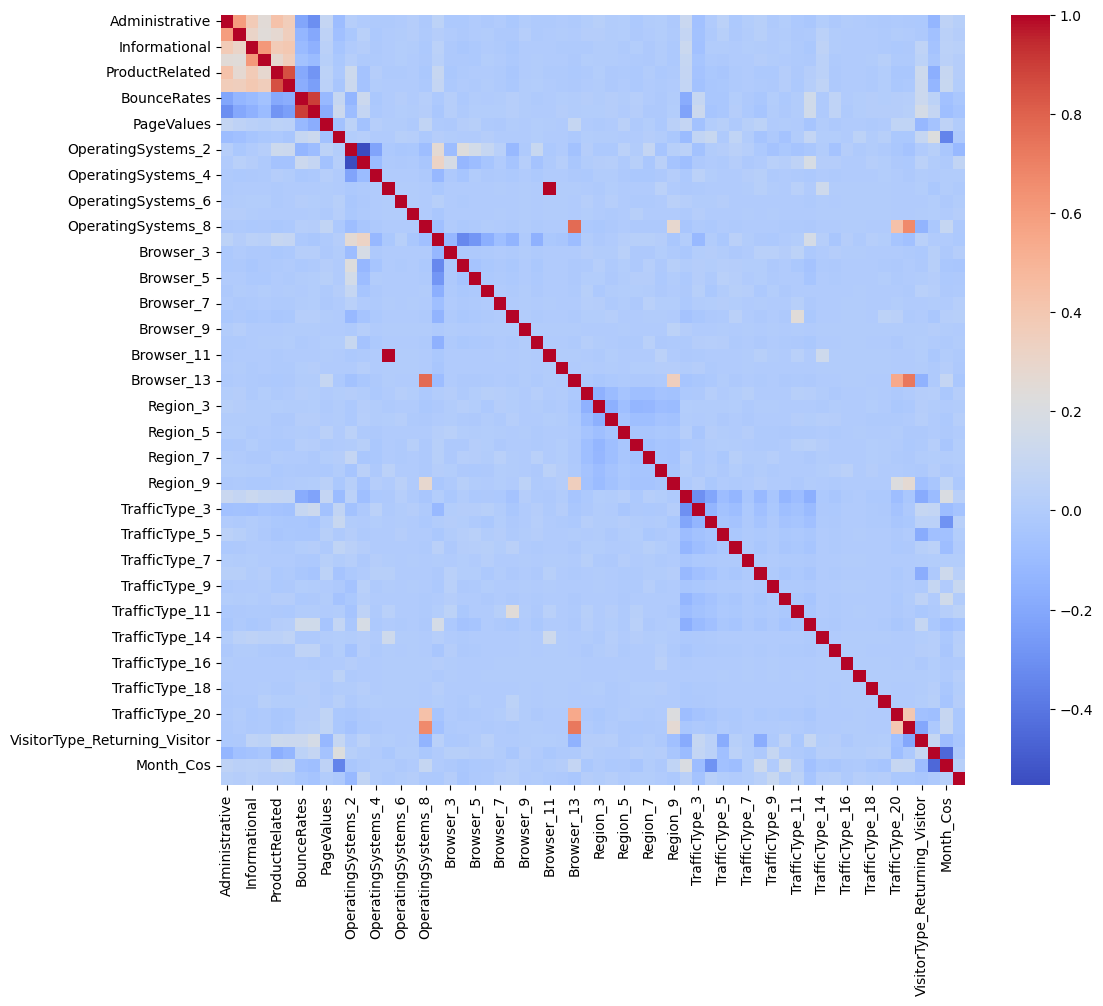

In [8]:
correlation_matrix = X_train_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", fmt=".2f")

In [14]:
# Integracja zmiennej docelowej z przetworzoną przestrzenią cech
X_train_df['Revenue'] = y_train
X_test_df['Revenue'] = y_test

# Eksport macierzy do formatu CSV
X_train_df.to_csv('online_shoppers_train_processed.csv', index=False)
X_test_df.to_csv('online_shoppers_test_processed.csv', index=False)